In [10]:
import os
import numpy as np

def load_bonn_dataset(path):

    X = []
    y = []

    folder_labels = {
        "A_Z":0,
        "B_O":0,
        "C_N":1,
        "D_F":1,
        "E_S":2
    }

    for folder,label in folder_labels.items():

        folder_path = os.path.join(path, folder)

        for file in os.listdir(folder_path):

            if file.endswith(".txt"):

                signal = np.loadtxt(os.path.join(folder_path,file))

                X.append(signal)
                y.append(label)

    return np.array(X), np.array(y)


X,y = load_bonn_dataset(r"E:\Downloads\BONN dataset")

print(X.shape)

(400, 4097)


In [11]:
import antropy as ant
from scipy.stats import skew, kurtosis

def hjorth(signal):

    diff1 = np.diff(signal)
    diff2 = np.diff(diff1)

    var0 = np.var(signal)
    var1 = np.var(diff1)
    var2 = np.var(diff2)

    mobility = np.sqrt(var1/var0)
    complexity = np.sqrt(var2/var1)/mobility

    return [var0,mobility,complexity]


def extract_features(signal):

    features = []

    # statistical
    features.append(np.mean(signal))
    features.append(np.std(signal))
    features.append(np.var(signal))
    features.append(np.max(signal))
    features.append(np.min(signal))
    features.append(np.ptp(signal))

    # extra stats
    features.append(skew(signal))
    features.append(kurtosis(signal))

    # Hjorth
    features.extend(hjorth(signal))

    # entropy
    features.append(ant.sample_entropy(signal))
    features.append(ant.perm_entropy(signal,normalize=True))
    features.append(ant.spectral_entropy(signal,sf=173,method="fft"))

    return features


X_features = np.array([extract_features(s) for s in X])

print(X_features.shape)

(400, 14)


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train,X_test,y_train,y_test = train_test_split(

    X_features,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, Add, Multiply, Softmax
from tensorflow.keras.models import Model


def attention_block(x):

    score = Dense(x.shape[-1],activation="tanh")(x)

    weights = Softmax(axis=1)(score)

    context = Multiply()([x,weights])

    return context



def residual_block(x,units):

    shortcut = x

    x = Dense(units,activation="relu")(x)
    x = BatchNormalization()(x)

    x = Dense(units,activation="relu")(x)
    x = BatchNormalization()(x)

    x = Add()([x,shortcut])

    return x



def build_model(input_dim,num_classes):

    inputs = Input(shape=(input_dim,))

    x = Dense(128,activation="relu")(inputs)
    x = BatchNormalization()(x)

    x = attention_block(x)

    x = residual_block(x,128)

    x = Dense(64,activation="relu")(x)
    x = BatchNormalization()(x)

    x = Dropout(0.3)(x)

    x = Dense(32,activation="relu")(x)

    outputs = Dense(num_classes,activation="softmax")(x)

    model = Model(inputs,outputs)

    model.compile(

        optimizer=tf.keras.optimizers.Adam(0.0005),

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]
    )

    return model


model = build_model(X_train.shape[1],len(np.unique(y)))

model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 14)]         0           []                               
                                                                                                  
 dense_7 (Dense)                (None, 128)          1920        ['input_2[0][0]']                
                                                                                                  
 batch_normalization_4 (BatchNo  (None, 128)         512         ['dense_7[0][0]']                
 rmalization)                                                                                     
                                                                                                  
 dense_8 (Dense)                (None, 128)          16512       ['batch_normalization_4[0][

In [14]:
early_stop = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=15,

    restore_best_weights=True
)


history = model.fit(

    X_train,
    y_train,

    epochs=200,

    batch_size=32,

    validation_split=0.2,

    callbacks=[early_stop]
)

Epoch 1/200
8/8 [==============================] - 1s 52ms/step - loss: 1.0515 - accuracy: 0.5273 - val_loss: 1.0958 - val_accuracy: 0.4844
Epoch 2/200
8/8 [==============================] - 0s 17ms/step - loss: 0.5203 - accuracy: 0.8242 - val_loss: 1.0953 - val_accuracy: 0.5000
Epoch 3/200
8/8 [==============================] - 0s 15ms/step - loss: 0.3353 - accuracy: 0.8672 - val_loss: 1.0926 - val_accuracy: 0.5000
Epoch 4/200
8/8 [==============================] - 0s 15ms/step - loss: 0.2414 - accuracy: 0.9258 - val_loss: 1.0903 - val_accuracy: 0.5000
Epoch 5/200
8/8 [==============================] - 0s 14ms/step - loss: 0.1793 - accuracy: 0.9688 - val_loss: 1.0882 - val_accuracy: 0.5000
Epoch 6/200
8/8 [==============================] - 0s 12ms/step - loss: 0.1515 - accuracy: 0.9648 - val_loss: 1.0863 - val_accuracy: 0.5000
Epoch 7/200
8/8 [==============================] - 0s 13ms/step - loss: 0.1429 - accuracy: 0.9531 - val_loss: 1.0883 - val_accuracy: 0.5781
Epoch 8/200
8/8 [===

In [15]:
from sklearn.metrics import accuracy_score,classification_report

pred = model.predict(X_test)

pred = np.argmax(pred,axis=1)

print("DL Accuracy:",accuracy_score(y_test,pred))

print(classification_report(y_test,pred))

3/3 [==============================] - 0s 3ms/step
DL Accuracy: 0.975
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        40
           1       0.95      1.00      0.98        20
           2       1.00      0.95      0.97        20

    accuracy                           0.97        80
   macro avg       0.98      0.97      0.97        80
weighted avg       0.98      0.97      0.97        80



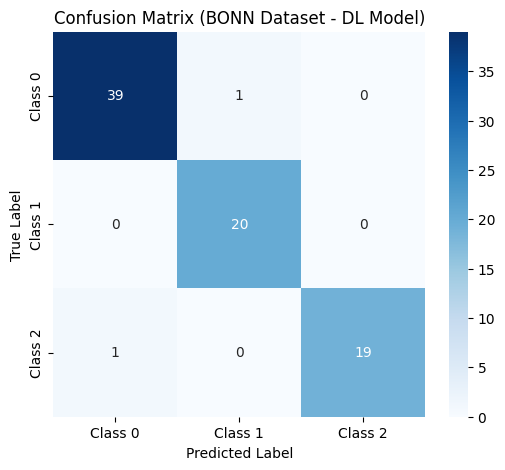

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# confusion matrix
cm = confusion_matrix(y_test, pred)

# plot
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Class 0","Class 1","Class 2"],
            yticklabels=["Class 0","Class 1","Class 2"])

plt.title("Confusion Matrix (BONN Dataset - DL Model)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

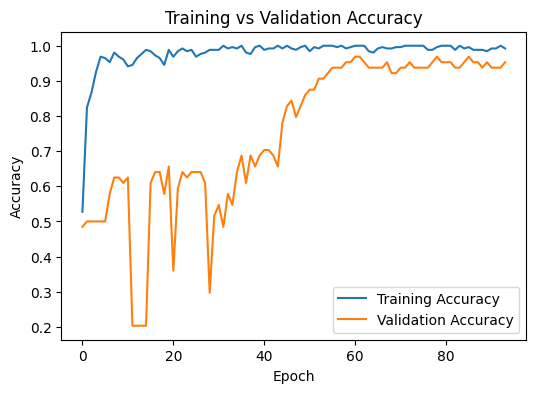

In [18]:
plt.figure(figsize=(6,4))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()